# Blue Team Design Notebook  -  Operation GRIDLOCK

---

### Your task

Design the supply network that routes supply from 4 source warehouses (corners) to 9 demand districts. You choose which relay candidates to activate and how to connect everything with links.

### Two decisions per link

| Property | Options | Effect |
|----------|---------|--------|
| **Capacity** | 1 / 2 / 3 | Flow it can carry; also scales build cost |
| **Armored** | True / False | `True` = immune to attack, but construction costs ×2.5 |

### What the Red Team can do

The Red Team may attack **any unarmored link** in the network -- source→relay, relay→relay, or relay→sink. If you want a link to be immune, armor it (at 2.5× cost). If you rely on a single unarmored source→relay link, it can be severed for 10u, cutting off everything downstream.

| Action | Target | Effect | Cost |
|--------|--------|--------|------|
| sever | any unarmored link | Permanently removes it | 10u (flat) |
| degrade | any unarmored link | Halves capacity | 5u (flat) |

Attack costs are **flat** -- a long link costs the same to sever as a short one.

### Workflow
1. **Setup** -- read the cost table, study the map
2. **Section A** -- choose relay nodes
3. **Section B** -- design links (cap + armored for each)
4. **Validate** -- check budget and connectivity
5. **Map** -- visualise your network
6. **Export** -- save CSV before class
7. *(In class)* **Quick Adjustment** after budget reveal

In [1]:
from gridlock_core import *
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import glob, os
print('Notebook ready.')

Notebook ready.


---
## Canvas -- study the map before designing

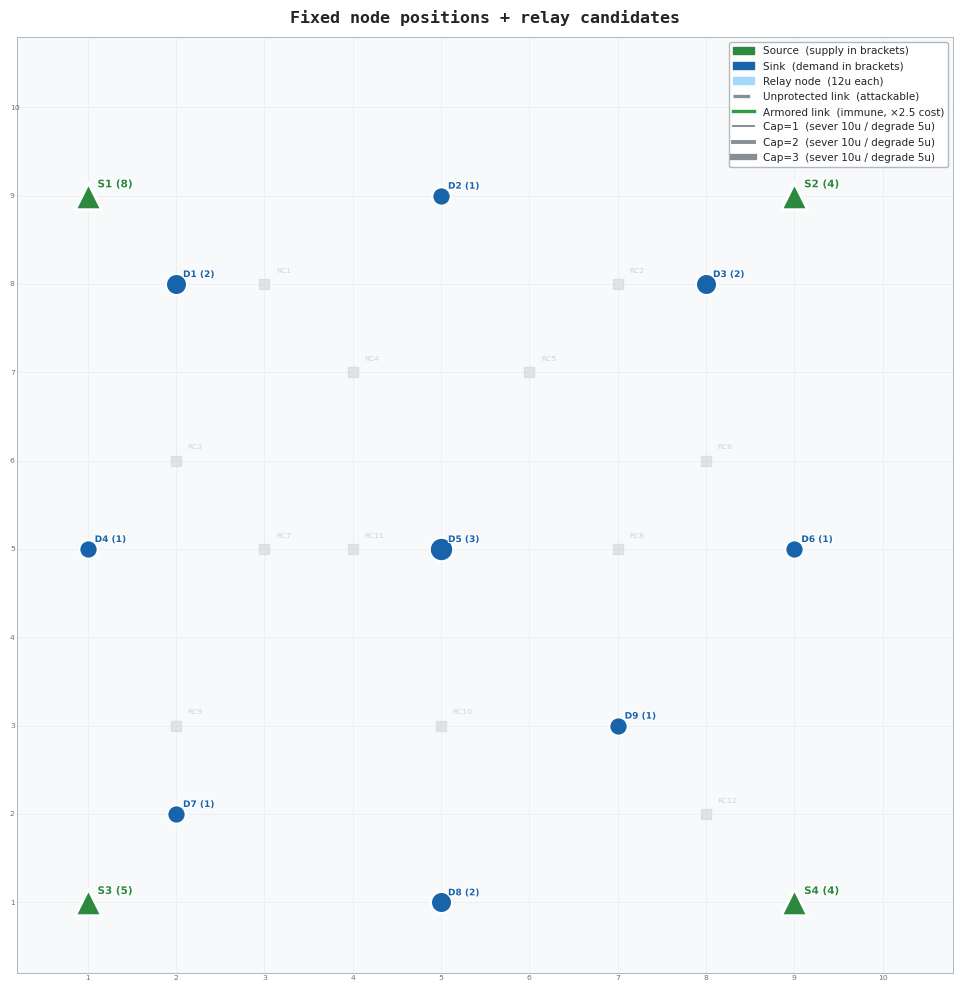

Relay candidates (choose 6-10 to activate at 12 u each):
  RC1   at (3,8)
  RC2   at (7,8)
  RC3   at (2,6)
  RC4   at (4,7)
  RC5   at (6,7)
  RC6   at (8,6)
  RC7   at (3,5)
  RC8   at (7,5)
  RC9   at (2,3)
  RC10  at (5,3)
  RC11  at (4,5)
  RC12  at (8,2)

Sample build costs  (unprotected | armored):
  S1--RC1  cap=2  unprotected=9u  armored=22u  (dist=2.24)
  S4--RC12  cap=2  unprotected=6u  armored=15u  (dist=1.41)
  RC1--RC11  cap=2  unprotected=13u  armored=32u  (dist=3.16)
  RC9--RC10  cap=1  unprotected=6u  armored=15u  (dist=3.0)
  RC6--RC12  cap=3  unprotected=24u  armored=60u  (dist=4.0)


In [2]:
fig, ax = plt.subplots(figsize=(11, 10), facecolor="white")
_empty_n = pd.DataFrame(columns=["id","role","x","y","label"])
_empty_e = pd.DataFrame(columns=["id","source","target","cap","armored"])
draw_network(_empty_n, _empty_e, ax=ax,
             title="Fixed node positions + relay candidates",
             show_candidates=True)
plt.tight_layout()
plt.savefig("canvas.png", dpi=130, bbox_inches="tight", facecolor="white")
plt.show()
print("Relay candidates (choose 6-10 to activate at", RELAY_NODE_COST, "u each):")
for cid, cv in RELAY_CANDIDATES.items():
    print("  " + cid.ljust(5) + " at (" + str(cv["x"]) + "," + str(cv["y"]) + ")")
print()
print("Sample build costs  (unprotected | armored):")
for a, b, c in [("S1","RC1",2), ("S4","RC12",2), ("RC1","RC11",2),
                ("RC9","RC10",1), ("RC6","RC12",3)]:
    _d = round(__import__("math").sqrt(
        (POSITIONS[a][0]-POSITIONS[b][0])**2
        + (POSITIONS[a][1]-POSITIONS[b][1])**2), 2)
    _u = link_build_cost(a, b, c, False)
    _r = link_build_cost(a, b, c, True)
    print("  " + a + "--" + b + "  cap=" + str(c)
          + "  unprotected=" + str(_u) + "u  armored=" + str(_r) + "u"
          + "  (dist=" + str(_d) + ")")

---
## Section A -- Choose Relay Nodes  *(edit this cell)*

All relays cost **12u** each. No distinction between types -- relay nodes cannot be attacked, only links can.

In [3]:
# ============================================================
#  SECTION A  --  CHOOSE YOUR RELAYS  (edit this cell)
# ============================================================
# Relay node cost: 12u each (all same type; no node attacks exist).
# Choose 6-10 from the 12 candidates.

TEAM_ID   = "BT1"
TEAM_NAME = "My Team"

RESILIENCE_STRATEGY = "redundancy"   # redundancy | armoring | mixed

DESIGN_RATIONALE = (
    "Explain your strategy here (min 60 chars, graded). "
    "Which paths did you armor vs. leave unprotected? "
    "How do you ensure D5 (demand=3) stays served? "
    "How does your design hold up across the attack budget range?"
)

MY_RELAYS = [
    # candidate_id
    "RC1", "RC2", "RC3", "RC6", "RC9", "RC10", "RC11", "RC12",
]


---
## Section B -- Design Links  *(edit this cell)*

Each link: `(id, source, target, cap, armored)`

| cap | Unprotected build | Armored build | Sever cost | Degrade cost |
|-----|------------------|--------------|-----------|--------------|
| 1 | max(3, dist×2) | ×2.5 | **10u** | **5u** |
| 2 | max(6, dist×4) | ×2.5 | **10u** | **5u** |
| 3 | max(10, dist×6) | ×2.5 | **10u** | **5u** |

**Any unarmored link can be attacked** regardless of where it sits in the network. Armoring a link makes it completely immune.

In [4]:
# ============================================================
#  SECTION B  --  DESIGN YOUR LINKS  (edit this cell)
# ============================================================
#
# Each link: (id, source, target, cap, armored)
#   id      : any unique string
#   source  : any source (S1-S4), relay (RC1-RC12), or sink (D1-D9)
#   target  : same
#   cap     : 1 | 2 | 3        -- flow capacity and cost scale
#   armored : True | False      -- immune to attack but costs 2.5x more
#
# COST TABLE  (unprotected | armored):
#   cap=1: max(3,  dist×2)  |  ×2.5    sever=10u  degrade=5u
#   cap=2: max(6,  dist×4)  |  ×2.5    sever=10u  degrade=5u
#   cap=3: max(10, dist×6)  |  ×2.5    sever=10u  degrade=5u
#
# ATTACK RULE: any unarmored link (ANY position in network) can be attacked.
#   A source→relay→sink chain is only unattackable if ALL its links are armored.
#   Armoring is expensive -- balance armor with redundancy.
#
# HARD RULE: no direct source→sink links (validation enforces this).
#
# Preview link cost before committing:
#   link_build_cost("RC1", "RC11", cap=2, armored=False)

MY_EDGES = [
    # id            source    target  cap  armored
    # -- Source connections --
    ("S1-RC1",     "S1",    "RC1",    3,   True),
    ("S1-RC3",     "S1",    "RC3",    3,   False),
    ("S2-RC2",     "S2",    "RC2",    3,   True),
    ("S2-RC6",     "S2",    "RC6",    3,   False),
    ("S3-RC9",     "S3",    "RC9",    3,   True),
    ("S4-RC12",    "S4",    "RC12",   3,   True),
    # -- Relay backbone --
    ("RC1-RC11",   "RC1",   "RC11",   2,   False),
    ("RC2-RC11",   "RC2",   "RC11",   2,   False),
    ("RC3-RC9",    "RC3",   "RC9",    2,   False),
    ("RC6-RC11",   "RC6",   "RC11",   2,   False),
    ("RC6-RC12",   "RC6",   "RC12",   2,   False),
    ("RC9-RC10",   "RC9",   "RC10",   2,   False),
    ("RC10-RC11",  "RC10",  "RC11",   2,   False),
    ("RC11-RC12",  "RC11",  "RC12",   2,   False),
    # -- Sink connections --
    ("RC1-D1",     "RC1",   "D1",     2,   False),
    ("RC1-D2",     "RC1",   "D2",     1,   False),
    ("RC2-D3",     "RC2",   "D3",     2,   False),
    ("RC3-D4",     "RC3",   "D4",     1,   False),
    ("RC11-D5",    "RC11",  "D5",     3,   False),
    ("RC6-D6",     "RC6",   "D6",     1,   False),
    ("RC9-D7",     "RC9",   "D7",     1,   False),
    ("RC10-D8",    "RC10",  "D8",     2,   False),
    ("RC12-D9",    "RC12",  "D9",     1,   False),
]


---
## Validate  *(run after editing A and B)*

In [5]:
nodes_rows = []
for cid in MY_RELAYS:
    if cid not in RELAY_CANDIDATES:
        print("ERROR: " + cid + " is not a valid relay candidate"); continue
    cv = RELAY_CANDIDATES[cid]
    nodes_rows.append({"id":cid,"role":"relay","x":cv["x"],"y":cv["y"],"label":cid})
nodes_df = pd.DataFrame(nodes_rows)
edges_df = pd.DataFrame(
    [(eid, s, t, int(c), bool(a)) for eid,s,t,c,a in MY_EDGES],
    columns=["id","source","target","cap","armored"])

errors = []
relay_ids = set(nodes_df["id"])
all_ids   = relay_ids | set(SOURCES) | set(SINKS)

if nodes_df.duplicated("id").any():
    errors.append("Duplicate relay ids: "
                  + str(nodes_df[nodes_df.duplicated("id")]["id"].tolist()))
if edges_df.duplicated("id").any():
    errors.append("Duplicate edge ids: "
                  + str(edges_df[edges_df.duplicated("id")]["id"].tolist()))
for r in edges_df.itertuples():
    if r.source not in all_ids: errors.append("Unknown source: " + r.id)
    if r.target not in all_ids: errors.append("Unknown target: " + r.id)
    if r.cap not in (1,2,3):    errors.append("Invalid cap (must be 1/2/3): " + r.id)
    if (r.source in SOURCES and r.target in SINKS) or        (r.source in SINKS and r.target in SOURCES):
        errors.append("Direct source-sink link not allowed: " + r.id)

node_cost = len(nodes_df) * RELAY_NODE_COST
edge_cost = sum(link_build_cost(r.source, r.target, int(r.cap), bool(r.armored))
                for r in edges_df.itertuples()
                if r.source in all_ids and r.target in all_ids)
total     = node_cost + edge_cost
remaining = BLUE_BUDGET - total
if total > BLUE_BUDGET:
    errors.append("Over budget: " + str(total) + " > " + str(BLUE_BUDGET))

G = nx.Graph()
G.add_nodes_from(all_ids)
for r in edges_df.itertuples():
    G.add_edge(r.source, r.target)
unreachable = [s for s in SINKS
               if not any(nx.has_path(G, src, s) for src in SOURCES)]
if unreachable:
    errors.append("Sinks unreachable: " + str(unreachable))

if len(DESIGN_RATIONALE.strip()) < 60:
    errors.append("DESIGN_RATIONALE too short (min 60 chars)")

n_arm = edges_df["armored"].sum()
n_unp = len(edges_df) - n_arm
cap_counts = edges_df["cap"].value_counts().to_dict()
print("=" * 56)
print("  Team:", TEAM_ID, "--", TEAM_NAME)
print("  Relays:  ", len(nodes_df), "×", RELAY_NODE_COST, "u =", node_cost, "u")
print("  Links:   ", len(edges_df),
      "  (" + str(n_arm) + " armored, " + str(n_unp) + " unprotected)")
print("  Caps:    ",
      "  ".join("cap" + str(c) + "×" + str(cap_counts.get(c,0))
                for c in [1,2,3]))
print("  Budget:  ", str(node_cost) + "u nodes + " + str(edge_cost) + "u links"
      + " = " + str(total) + "/" + str(BLUE_BUDGET) + "u"
      + "  (" + str(remaining) + " remaining)")
print("=" * 56)
if errors:
    for e in errors: print("  ERROR:", e)
else:
    p0 = compute_perf(nodes_df, edges_df, set(), set())
    pct = round(p0["fraction"] * 100)
    print("  All checks passed!")
    print("  Intact max-flow:", str(p0["flow"]) + "/" + str(TOTAL_DEMAND),
          "=", str(pct) + "%",
          "" if pct == 100 else "  WARNING: not 100%!")
    n_exposed = n_unp
    print("  Attack surface:", n_exposed, "unprotected links")


  Team: BT1 -- My Team
  Relays:   8 × 12 u = 96 u
  Links:    23   (4 armored, 19 unprotected)
  Caps:     cap1×5  cap2×11  cap3×7
  Budget:   96u nodes + 320u links = 416/500u  (84 remaining)
  All checks passed!
  Intact max-flow: 14.0/14 = 100% 
  Attack surface: 19 unprotected links


---
## Network Map  *(run after validate)*

Colour = protection (grey = attackable, green = armored). Width = capacity (thin=1, medium=2, thick=3).

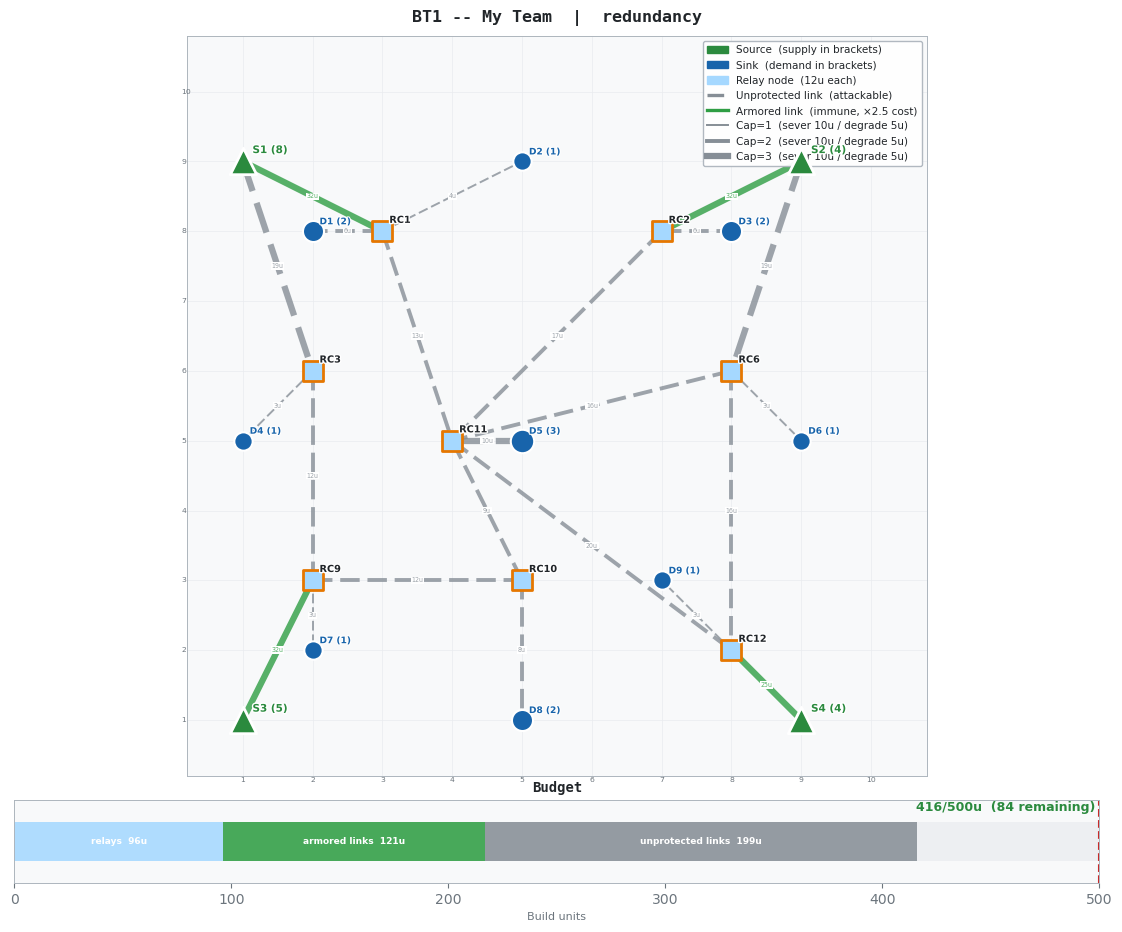

In [6]:
node_cost = len(nodes_df) * RELAY_NODE_COST
edge_cost = sum(link_build_cost(r.source, r.target, int(r.cap), bool(r.armored))
                for r in edges_df.itertuples())
total     = node_cost + edge_cost
remaining = BLUE_BUDGET - total
breakdown = [
    ("relays",
     node_cost, PAL["relay_fill"]),
    ("armored links",
     sum(link_build_cost(r.source, r.target, int(r.cap), True)
         for r in edges_df[edges_df["armored"]==True].itertuples()),
     PAL["armored"]),
    ("unprotected links",
     sum(link_build_cost(r.source, r.target, int(r.cap), False)
         for r in edges_df[edges_df["armored"]==False].itertuples()),
     PAL["unprotected"]),
]
fig = plt.figure(figsize=(14, 11), facecolor="white")
gs  = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[9,1], hspace=0.06)
ax_map = fig.add_subplot(gs[0])
ax_bgt = fig.add_subplot(gs[1])
draw_network(nodes_df, edges_df, ax=ax_map,
             title=TEAM_ID + " -- " + TEAM_NAME + "  |  " + RESILIENCE_STRATEGY,
             show_candidates=False)
draw_budget_bar(total, BLUE_BUDGET, breakdown, ax=ax_bgt)
plt.savefig(TEAM_ID + "_design.png", dpi=130,
            bbox_inches="tight", facecolor="white")
plt.show()


---
## Export CSV  *(run last before class)*

In [24]:
def _net_csv(team_id, team_name, strategy, rationale, nodes_df, edges_df):
    import pandas as pd
    cols = ["record","id","value","role","x","y","label",
            "source","target","cap","armored"]
    def m(k, v):
        row = {c:"" for c in cols}; row.update({"record":"META","id":k,"value":str(v)}); return row
    def n(r):
        row = {c:"" for c in cols}
        row.update({"record":"NODE","id":r.id,"role":r.role,
                    "x":r.x,"y":r.y,"label":r.label}); return row
    def e(r):
        row = {c:"" for c in cols}
        row.update({"record":"EDGE","id":r.id,"source":r.source,"target":r.target,
                    "cap":int(r.cap),"armored":bool(r.armored)}); return row
    rows = ([m("team_id",team_id), m("team_name",team_name),
             m("strategy",strategy),
             m("rationale",rationale.strip().replace("\n"," "))]
            + [n(r) for r in nodes_df.itertuples()]
            + [e(r) for r in edges_df.itertuples()])
    return pd.DataFrame(rows)[cols]


def _atk_csv(rt_id, bt_id, plan_name, pred_min, vuln, steps):
    import pandas as pd
    cols = ["record","step","id","value","target_type","target_id","action","rationale"]
    def m(k,v):
        row={c:"" for c in cols}; row.update({"record":"META","id":k,"value":str(v)}); return row
    def a(s,tt,tid,act,rat):
        row={c:"" for c in cols}
        row.update({"record":"ATTACK","step":s,"target_type":tt,
                    "target_id":tid,"action":act,"rationale":rat}); return row
    rows = ([m("red_team_id",rt_id), m("target_team_id",bt_id),
             m("chosen_plan",plan_name), m("predicted_min",pred_min),
             m("vuln_analysis",vuln.strip().replace("\n"," "))]
            + [a(s,tt,tid,act,rat) for s,tt,tid,act,rat in steps])
    return pd.DataFrame(rows)[cols]

df    = _net_csv(TEAM_ID, TEAM_NAME, RESILIENCE_STRATEGY,
                 DESIGN_RATIONALE, nodes_df, edges_df)
fname = TEAM_ID + "_network.csv"
df.to_csv(fname, index=False)
print("Saved ->", fname)
print("Upload to Google Drive before class.")


Saved -> BT1_network.csv
Upload to Google Drive before class.
